<a href="https://colab.research.google.com/github/yaongjoo/2D-FaltFormer/blob/main/3%EC%A3%BC%EC%B0%A8_Tidy_Data_Messy_Data_%EC%8B%A4%EC%8A%B5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 3주차 실습: 데이터 구조의 이해와 Tidy Data 전처리

- 실습 주제: **Tidy Data 원칙 이해 + Messy Data 5가지 패턴 해결**
- 사용 데이터: **2024_BRFSS_CLEANED.csv** (실제 CSV)
- 핵심 목표:
  - `1행 = 1관측치`, `1열 = 1변수`, `서로 다른 관측 단위는 분리`라는 원칙을 실제 코드로 확인한다.
  - `melt`, `pivot`, `concat`, `drop_duplicates`, `merge`, `str.extract`를 이용해 messy data를 tidy data로 복구한다.
  - 단순히 "코드가 돌아가는가"가 아니라, **왜 이 구조가 시각화/분석/모델링에 유리한가**까지 함께 이해한다.

---

## 이번 노트북의 진행 방식

1. **개념 설명 (Markdown)**
2. **직접 실행하는 코드 셀**
3. **🤔 생각해 보기**
4. **해설/검증 코드**
5. **결과 해석**

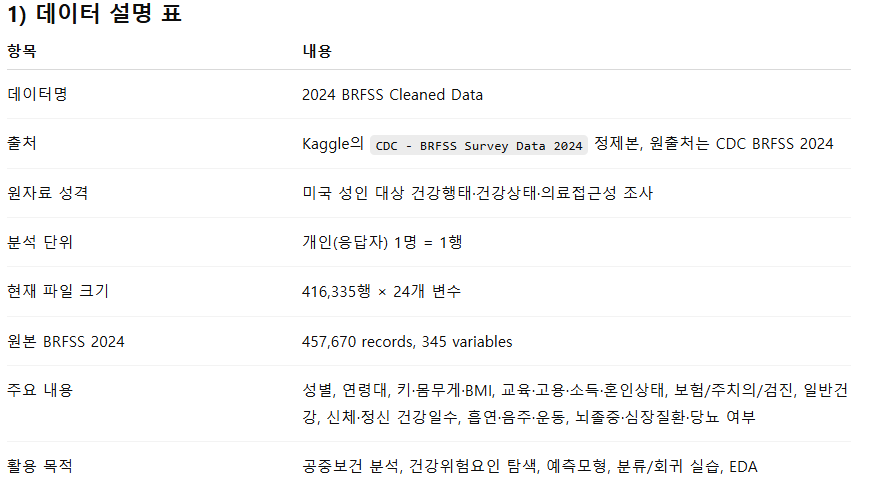

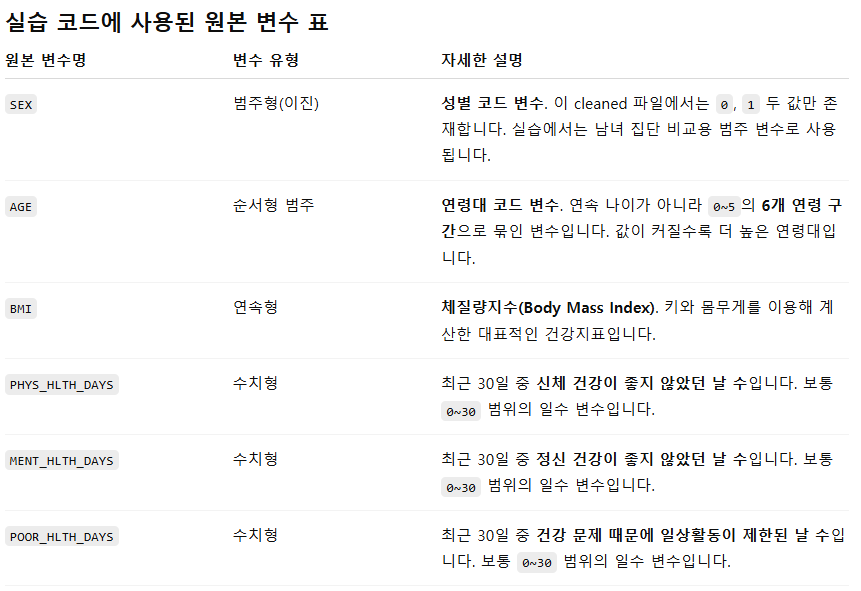

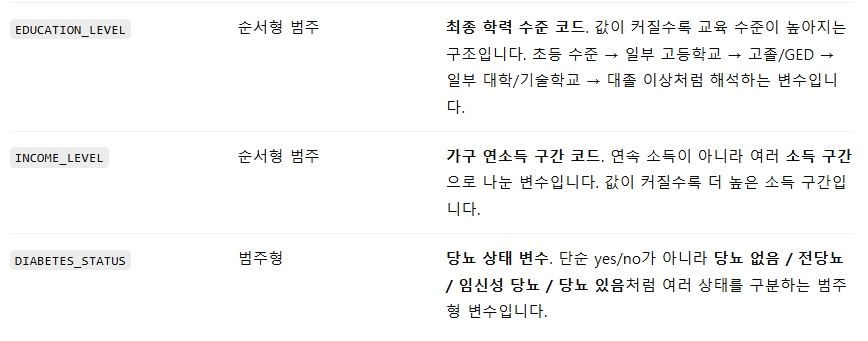

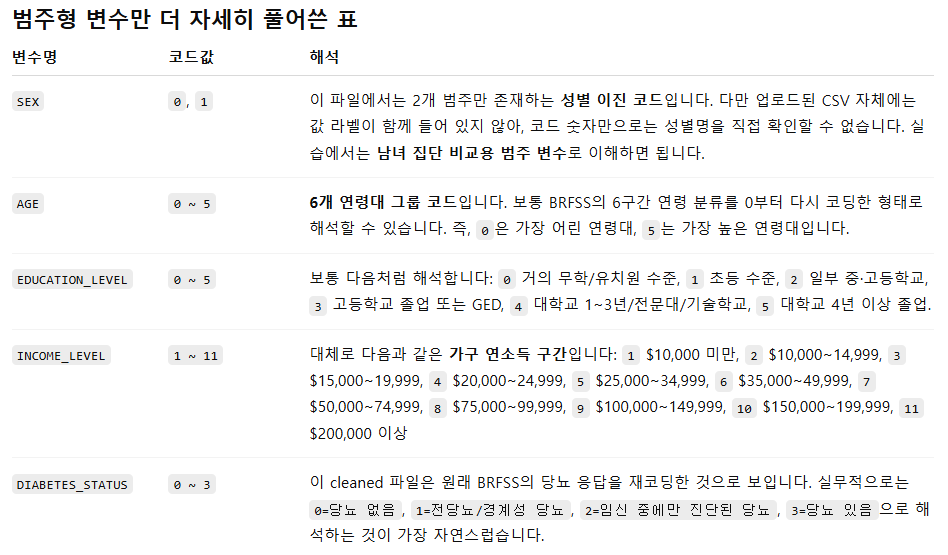

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 120)
pd.set_option('display.max_colwidth', 100)

candidate_paths = [
    Path("2024_BRFSS_CLEANED.csv"),
    Path("./2024_BRFSS_CLEANED.csv"),
    Path("/mnt/data/2024_BRFSS_CLEANED.csv"),
]

DATA_PATH = None
for path in candidate_paths:
    if path.exists():
        DATA_PATH = path.resolve()
        break

if DATA_PATH is None:
    raise FileNotFoundError(
        "'2024_BRFSS_CLEANED.csv'를 찾지 못했습니다. "
        "노트북과 CSV 파일을 같은 폴더에 두거나, 파일 경로를 직접 수정하세요."
    )

BASE_DIR = DATA_PATH.parent

print("데이터 파일 경로:", DATA_PATH)
print("BASE_DIR:", BASE_DIR)

데이터 파일 경로: /mnt/data/2024_BRFSS_CLEANED.csv
BASE_DIR: /mnt/data


# 1. 원본 CSV 불러오기와 구조 확인

실무 전처리에서 가장 먼저 해야 하는 일은 **구조 파악(Discovering)** 입니다.

이 단계에서 반드시 확인해야 할 질문은 다음과 같습니다.

- 데이터는 몇 행, 몇 열인가?
- 어떤 열이 수치형이고 어떤 열이 범주형인가?
- 결측치가 많은 열은 무엇인가?
- 열 이름이 분석 목적에 맞게 읽히는가?
- 지금 구조가 바로 시각화 가능한 tidy form인가?

전처리는 청소가 아니라 **설계**이므로, 무작정 `dropna()`부터 하기보다 먼저 구조를 읽어야 합니다.

In [ ]:
raw = pd.read_csv(DATA_PATH)
print("행, 열 크기:", raw.shape)
raw.head()

행, 열 크기: (416335, 24)


,YEAR,SEX,AGE,WGHT (lbs),HGHT (ft),BMI,EDUCATION_LEVEL,EMPLOYMENT_STATUS,INCOME_LEVEL,MARITAL_STATUS,INSR_STATUS,DCTR_STATUS,COST_STATUS,CHKP_STATUS,GEN_HLTH,PHYS_HLTH_DAYS,MENT_HLTH_DAYS,POOR_HLTH_DAYS,SMOK_STATUS,ALHL_STATUS,EXER_STATUS,HAD_STROKE,HAD_HEARTDISEASE,DIABETES_STATUS
0,2024,0,5,131.0,5.33,22.51,3.0,7.0,NaN,3.0,3.0,2.0,0.0,1.0,3.0,2.0,0.0,0.0,0.0,NaN,1.0,0.0,0.0,0
1,2024,1,5,180.0,5.83,25.85,5.0,7.0,11.0,1.0,3.0,1.0,0.0,1.0,5.0,0.0,0.0,NaN,1.0,NaN,1.0,0.0,1.0,0
2,2024,1,4,195.0,6.50,22.53,4.0,1.0,NaN,6.0,1.0,0.0,1.0,4.0,4.0,30.0,0.0,1.0,3.0,2.0,1.0,0.0,0.0,0
3,2024,1,5,165.0,5.67,25.06,5.0,7.0,6.0,1.0,3.0,1.0,0.0,1.0,5.0,0.0,0.0,NaN,0.0,NaN,1.0,0.0,0.0,0
4,2024,1,3,130.0,5.67,19.74,4.0,0.0,3.0,5.0,5.0,1.0,0.0,1.0,3.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,0.0,0


In [ ]:
raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 416335 entries, 0 to 416334
Data columns (total 24 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   YEAR               416335 non-null  int64  
 1   SEX                416335 non-null  int64  
 2   AGE                416335 non-null  int64  
 3   WGHT (lbs)         416335 non-null  float64
 4   HGHT (ft)          416335 non-null  float64
 5   BMI                416335 non-null  float64
 6   EDUCATION_LEVEL    415110 non-null  float64
 7   EMPLOYMENT_STATUS  413100 non-null  float64
 8   INCOME_LEVEL       352719 non-null  float64
 9   MARITAL_STATUS     413955 non-null  float64
 10  INSR_STATUS        401539 non-null  float64
 11  DCTR_STATUS        412680 non-null  float64
 12  COST_STATUS        415071 non-null  float64
 13  CHKP_STATUS        412168 non-null  float64
 14  GEN_HLTH           415333 non-null  float64
 15  PHYS_HLTH_DAYS     407163 non-null  float64
 16  ME

In [ ]:
missing_summary = (
    raw.isna()
       .sum()
       .to_frame("missing_count")
       .assign(missing_ratio=lambda x: (x["missing_count"] / len(raw)).round(4))
       .sort_values("missing_count", ascending=False)
)

missing_summary

,missing_count,missing_ratio
ALHL_STATUS,217094,0.5214
POOR_HLTH_DAYS,175047,0.4204
INCOME_LEVEL,63616,0.1528
SMOK_STATUS,15246,0.0366
INSR_STATUS,14796,0.0355
PHYS_HLTH_DAYS,9172,0.0220
MENT_HLTH_DAYS,6634,0.0159
CHKP_STATUS,4167,0.0100
HAD_HEARTDISEASE,3823,0.0092
DCTR_STATUS,3655,0.0088


# 데이터 구조를 실습하기 좋게 일부 열만 선택

원본 CSV에는 여러 열이 있지만, 이번 3주차 실습에서는 다음 열들을 중심으로 사용합니다.

- `SEX`, `AGE` : 범주형 코드
- `BMI` : 대표 수치형 변수
- `PHYS_HLTH_DAYS`, `MENT_HLTH_DAYS`, `POOR_HLTH_DAYS` : 건강 관련 일수 변수
- `EDUCATION_LEVEL`, `INCOME_LEVEL`, `DIABETES_STATUS` : 집단별 비교에 활용할 변수

또한 실습 편의를 위해 `RESPONDENT_ID`를 새로 부여합니다.


이 ID는 원본 CSV의 공식 변수는 아니고,
**행 식별을 위한 실습용 키(primary key 역할)** 입니다.

In [ ]:
brfss = (
    raw[
        [
            "SEX", "AGE", "BMI",
            "PHYS_HLTH_DAYS", "MENT_HLTH_DAYS", "POOR_HLTH_DAYS",
            "EDUCATION_LEVEL", "INCOME_LEVEL", "DIABETES_STATUS"
        ]
    ]
    .copy()
)

brfss.insert(0, "RESPONDENT_ID", np.arange(1, len(brfss) + 1))

brfss = brfss.rename(
    columns={
        "SEX": "SEX_CODE",
        "AGE": "AGE_CODE",
        "EDUCATION_LEVEL": "EDU_LEVEL_CODE",
        "INCOME_LEVEL": "INCOME_LEVEL_CODE"
    }
)

print("실습용 데이터 크기:", brfss.shape)
brfss.head()

실습용 데이터 크기: (416335, 10)


,RESPONDENT_ID,SEX_CODE,AGE_CODE,BMI,PHYS_HLTH_DAYS,MENT_HLTH_DAYS,POOR_HLTH_DAYS,EDU_LEVEL_CODE,INCOME_LEVEL_CODE,DIABETES_STATUS
0,1,0,5,22.51,2.0,0.0,0.0,3.0,NaN,0
1,2,1,5,25.85,0.0,0.0,NaN,5.0,11.0,0
2,3,1,4,22.53,30.0,0.0,1.0,4.0,NaN,0
3,4,1,5,25.06,0.0,0.0,NaN,5.0,6.0,0
4,5,1,3,19.74,0.0,0.0,NaN,4.0,3.0,0


# 🤔 생각해 보기

1. 현재 `brfss`는 이미 상당 부분 tidy data에 가깝습니다. 왜 그렇게 볼 수 있을까요?
2. 반대로, 이 데이터가 있다고 해서 바로 모든 분석이 쉬운 것은 아닙니다. 어떤 열은 왜 추가 정제가 필요할까요?
3. `RESPONDENT_ID`를 만든 이유는 무엇일까요? 단순 번호 붙이기와 구조 설계는 어떻게 다를까요?

In [ ]:
# 해설
print("1) 현재 구조는 기본적으로 1행=1응답자, 1열=1변수 형태이므로 tidy data에 가깝습니다.")
print("2) 하지만 결측치, 코드형 범주(예: AGE_CODE, SEX_CODE), 분석 목적별 집계 구조 변환은 여전히 필요합니다.")
print("3) RESPONDENT_ID는 관측치를 구분하는 식별자 역할을 하며, merge/검증/중복 확인 시 매우 중요합니다.")

1) 현재 구조는 기본적으로 1행=1응답자, 1열=1변수 형태이므로 tidy data에 가깝습니다.
2) 하지만 결측치, 코드형 범주(예: AGE_CODE, SEX_CODE), 분석 목적별 집계 구조 변환은 여전히 필요합니다.
3) RESPONDENT_ID는 관측치를 구분하는 식별자 역할을 하며, merge/검증/중복 확인 시 매우 중요합니다.


# 2. 3주차 핵심 이론 요약: Tidy Data와 Messy Data

이번 주차의 핵심은 다음 두 문장으로 압축할 수 있습니다.

- **Tidy Data**
  - 1열 = 1변수
  - 1행 = 1관측치
  - 서로 다른 관측 단위는 다른 테이블로 분리
- **Messy Data**
  - 열 이름이 값이 되거나
  - 여러 변수가 한 열에 섞이거나
  - 변수가 행/열에 동시에 파편화되거나
  - 서로 다른 관측 단위가 한 표에 섞이거나
  - 동일 구조 데이터가 여러 파일에 쪼개져 있는 상태

즉, 이번 실습은 이미 정리된 실제 CSV를 다시 일부러 **messy하게 변형한 뒤**, 그 구조를 **복원하는 연습**입니다.
이 방식으로 공부하면 `melt`, `pivot`, `merge`, `concat`의 목적이 훨씬 명확해집니다.

In [ ]:
def memory_usage_mb(df):
    return df.memory_usage(deep=True).sum() / 1024**2

def print_basic_check(name, df):
    print(f"[{name}]")
    print("shape:", df.shape)
    print("memory(MB):", round(memory_usage_mb(df), 3))
    print("columns:", list(df.columns))
    print("-" * 80)

print_basic_check("brfss", brfss)

[brfss]
shape: (416335, 10)
memory(MB): 31.764
columns: ['RESPONDENT_ID', 'SEX_CODE', 'AGE_CODE', 'BMI', 'PHYS_HLTH_DAYS', 'MENT_HLTH_DAYS', 'POOR_HLTH_DAYS', 'EDU_LEVEL_CODE', 'INCOME_LEVEL_CODE', 'DIABETES_STATUS']
--------------------------------------------------------------------------------


# 3. 유형 1 실습
## 열 이름이 값(value)인 경우 → `melt()`로 해결

가장 흔한 안티 패턴은 **열 이름이 변수명이 아니라 값 자체가 되는 경우**입니다.

예를 들어 아래와 같이 `AGE_CODE` 값이 열 이름(`0`, `1`, `2`, `3`, `4`, `5`)으로 퍼져 있으면,
우리는 더 이상 `AGE_CODE`를 하나의 독립된 변수로 다루기 어렵습니다.

이번 실습에서는 실제 CSV에서 다음 구조를 일부러 만들겠습니다.

- 행: `SEX_CODE`
- 열: `AGE_CODE` 값들 (`0`, `1`, `2`, `3`, `4`, `5`)
- 셀 값: 평균 BMI

이 구조는 사람이 보기에 표처럼 읽기 쉽지만, 시각화/모델링에는 불리합니다.

In [ ]:
# 실제 CSV를 사용해 '유형 1' messy data 만들기
type1_source = brfss[["SEX_CODE", "AGE_CODE", "BMI"]].dropna()

type1_grouped = (
    type1_source
    .groupby(["SEX_CODE", "AGE_CODE"], as_index=False)["BMI"]
    .mean()
    .round(2)
)

type1_messy = (
    type1_grouped
    .pivot(index="SEX_CODE", columns="AGE_CODE", values="BMI")
    .reset_index()
)

# 열 이름을 '값'처럼 보이도록 문자열로 바꿔 저장
type1_messy.columns = ["SEX_CODE"] + [str(col) for col in type1_messy.columns[1:]]

type1_path = BASE_DIR / "messy_type1_bmi_by_agecode.csv"
type1_messy.to_csv(type1_path, index=False)

print("저장 완료:", type1_path.resolve())
type1_messy

저장 완료: /mnt/data/messy_type1_bmi_by_agecode.csv


,SEX_CODE,0,1,2,3,4,5
0,0,26.40,28.88,29.51,29.82,29.23,27.71
1,1,25.85,28.08,29.15,29.75,29.54,28.17


In [ ]:
messy1 = pd.read_csv(type1_path)
print_basic_check("messy1", messy1)
messy1

[messy1]
shape: (2, 7)
memory(MB): 0.0
columns: ['SEX_CODE', '0', '1', '2', '3', '4', '5']
--------------------------------------------------------------------------------


,SEX_CODE,0,1,2,3,4,5
0,0,26.40,28.88,29.51,29.82,29.23,27.71
1,1,25.85,28.08,29.15,29.75,29.54,28.17


## 왜 이 구조가 messy한가?

문제는 `0, 1, 2, 3, 4, 5`가 원래는 **AGE_CODE의 값**인데,
지금은 **열 이름**이 되어버렸다는 점입니다.

이렇게 되면 다음과 같은 불편이 생깁니다.

- `AGE_CODE`라는 변수를 x축에 바로 매핑하기 어렵다.
- 새로운 연령 코드가 추가되면 열이 계속 늘어난다.
- groupby, filter, plot 로직이 필요 이상으로 복잡해진다.

따라서 다시 다음 구조로 바꿔야 합니다.

- `SEX_CODE` : 기준 변수
- `AGE_CODE` : 새로 복원된 변수
- `MEAN_BMI` : 값

In [ ]:
# 해결 1단계: value로 퍼진 열들을 다시 하나의 변수(AGE_CODE)로 모은다.
age_value_columns = [col for col in messy1.columns if col != "SEX_CODE"]

tidy1 = (
    messy1
    .melt(
        id_vars="SEX_CODE",
        value_vars=age_value_columns,
        var_name="AGE_CODE",
        value_name="MEAN_BMI"
    )
    .dropna(subset=["MEAN_BMI"])
)

tidy1["AGE_CODE"] = tidy1["AGE_CODE"].astype(int)
tidy1 = tidy1.sort_values(["SEX_CODE", "AGE_CODE"]).reset_index(drop=True)

tidy1

,SEX_CODE,AGE_CODE,MEAN_BMI
0,0,0,26.40
1,0,1,28.88
2,0,2,29.51
3,0,3,29.82
4,0,4,29.23
5,0,5,27.71
6,1,0,25.85
7,1,1,28.08
8,1,2,29.15
9,1,3,29.75


In [ ]:
# 검증: tidy1이 원래 groupby 결과와 같은지 확인
expected1 = type1_grouped.rename(columns={"BMI": "MEAN_BMI"}).sort_values(["SEX_CODE", "AGE_CODE"]).reset_index(drop=True)

check1 = tidy1.merge(
    expected1,
    on=["SEX_CODE", "AGE_CODE", "MEAN_BMI"],
    how="outer",
    indicator=True
)

print(check1["_merge"].value_counts())
assert (check1["_merge"] == "both").all(), "유형 1 복원이 원래 집계 결과와 다릅니다."
print("검증 통과: melt 결과가 원래 집계와 정확히 일치합니다.")

_merge
both          12
left_only      0
right_only     0
Name: count, dtype: int64
검증 통과: melt 결과가 원래 집계와 정확히 일치합니다.


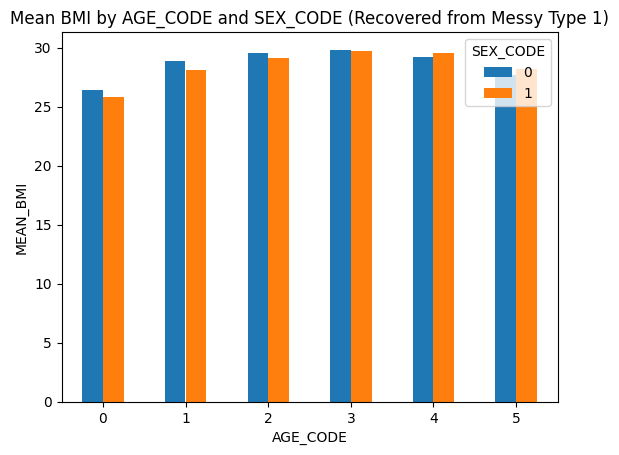

In [ ]:
# 시각화: tidy 구조가 되면 AGE_CODE를 x축 변수로 바로 사용할 수 있다.
pivot_plot1 = tidy1.pivot(index="AGE_CODE", columns="SEX_CODE", values="MEAN_BMI")

pivot_plot1.plot(kind="bar")
plt.title("Mean BMI by AGE_CODE and SEX_CODE (Recovered from Messy Type 1)")
plt.xlabel("AGE_CODE")
plt.ylabel("MEAN_BMI")
plt.xticks(rotation=0)
plt.legend(title="SEX_CODE")
plt.show()

# 해석:
# - tidy 구조가 되면 AGE_CODE가 하나의 독립된 열로 복원되어
#   x축, 색상, 그룹 변수로 쉽게 활용 가능하다.
# - 즉, melt는 단순 형태 변환이 아니라 '분석 가능한 변수의 복원'이다.

# 🤔 생각해 보기

1. `melt()`를 쓰지 않고도 이 문제를 해결할 수 있을까요?
2. 새로운 `AGE_CODE=6`이 등장하면 wide form과 long form 중 어느 쪽이 더 유연할까요?
3. 시각화 라이브러리가 long form을 선호하는 이유는 무엇일까요?

In [ ]:
print("1) 가능은 하지만, 반복문/수동 열 처리 방식은 유지보수성이 크게 떨어집니다.")
print("2) long form은 새로운 범주가 생겨도 '행 추가'로 대응되므로 확장성이 높습니다.")
print("3) 시각화에서는 x, y, color, facet에 매핑할 변수가 각각 독립 열이어야 하기 때문입니다.")

1) 가능은 하지만, 반복문/수동 열 처리 방식은 유지보수성이 크게 떨어집니다.
2) long form은 새로운 범주가 생겨도 '행 추가'로 대응되므로 확장성이 높습니다.
3) 시각화에서는 x, y, color, facet에 매핑할 변수가 각각 독립 열이어야 하기 때문입니다.


# 4. 유형 2 실습
## 여러 변수가 1개의 열에 융합된 경우 → `str.extract()`로 해결

이번에는 실제 CSV 일부를 사용해 **SEX_CODE와 AGE_CODE를 하나의 문자열 열에 합친 messy data**를 만들겠습니다.

예시 형태:
- `S0A5`
- `S1A3`

이 문자열에는 사실 두 개의 변수가 들어 있습니다.

- `SEX_CODE`
- `AGE_CODE`

겉으로는 한 열이지만, 실제로는 **두 변수의 정보가 압축되어 섞여 있는 상태**입니다.

In [ ]:
# 실제 CSV를 사용해 '유형 2' messy data 만들기
type2_source = (
    brfss[["SEX_CODE", "AGE_CODE", "BMI"]]
    .dropna()
    .sample(5000, random_state=42)
    .reset_index(drop=True)
)

type2_messy = pd.DataFrame({
    "DEMOGRAPHIC": "S" + type2_source["SEX_CODE"].astype(int).astype(str) + "A" + type2_source["AGE_CODE"].astype(int).astype(str),
    "BMI": type2_source["BMI"].round(2)
})

type2_path = BASE_DIR / "messy_type2_fused_demographic.csv"
type2_messy.to_csv(type2_path, index=False)

print("저장 완료:", type2_path.resolve())
type2_messy.head()

저장 완료: /mnt/data/messy_type2_fused_demographic.csv


,DEMOGRAPHIC,BMI
0,S1A0,30.46
1,S1A5,29.76
2,S0A5,22.15
3,S0A5,21.25
4,S0A5,33.89


In [ ]:
messy2 = pd.read_csv(type2_path)
print_basic_check("messy2", messy2)
messy2.head()

[messy2]


shape: (5000, 2)
memory(MB): 0.291
columns: ['DEMOGRAPHIC', 'BMI']
--------------------------------------------------------------------------------


,DEMOGRAPHIC,BMI
0,S1A0,30.46
1,S1A5,29.76
2,S0A5,22.15
3,S0A5,21.25
4,S0A5,33.89


## 왜 이 구조가 messy한가?

`DEMOGRAPHIC` 열은 한 개처럼 보이지만, 사실은

- 성별 코드
- 연령 코드

라는 **서로 다른 두 변수**를 동시에 담고 있습니다.

이 상태에서는 다음 분석이 불편합니다.

- 성별만 기준으로 BMI 평균 구하기
- 연령 코드만 기준으로 그룹 비교하기
- 성별 × 연령 교차 시각화하기

따라서 문자열을 분해해서 각각 독립 열로 만들어야 합니다.

In [ ]:
# 해결: 정규표현식으로 1개의 문자열 열에서 2개의 변수를 추출
tidy2 = messy2.copy()

tidy2[["SEX_CODE", "AGE_CODE"]] = tidy2["DEMOGRAPHIC"].str.extract(r"S(\d+)A(\d+)")
tidy2["SEX_CODE"] = tidy2["SEX_CODE"].astype(int)
tidy2["AGE_CODE"] = tidy2["AGE_CODE"].astype(int)

tidy2 = tidy2[["SEX_CODE", "AGE_CODE", "BMI"]]

tidy2.head()

,SEX_CODE,AGE_CODE,BMI
0,1,0,30.46
1,1,5,29.76
2,0,5,22.15
3,0,5,21.25
4,0,5,33.89


In [ ]:
# 검증: 원래 샘플 데이터와 동일한 그룹 평균이 나오는지 확인
expected2 = (
    type2_source
    .groupby(["SEX_CODE", "AGE_CODE"], as_index=False)["BMI"]
    .mean()
    .round(6)
    .sort_values(["SEX_CODE", "AGE_CODE"])
    .reset_index(drop=True)
)

result2 = (
    tidy2
    .groupby(["SEX_CODE", "AGE_CODE"], as_index=False)["BMI"]
    .mean()
    .round(6)
    .sort_values(["SEX_CODE", "AGE_CODE"])
    .reset_index(drop=True)
)

pd.testing.assert_frame_equal(expected2, result2)
print("검증 통과: 분리 전/후의 그룹 평균이 정확히 일치합니다.")
result2.head(10)

검증 통과: 분리 전/후의 그룹 평균이 정확히 일치합니다.


,SEX_CODE,AGE_CODE,BMI
0,0,0,25.112286
1,0,1,28.389000
2,0,2,29.243246
3,0,3,30.202738
4,0,4,29.338148
5,0,5,27.578702
6,1,0,26.416328
7,1,1,28.501987
8,1,2,29.293514
9,1,3,29.874197


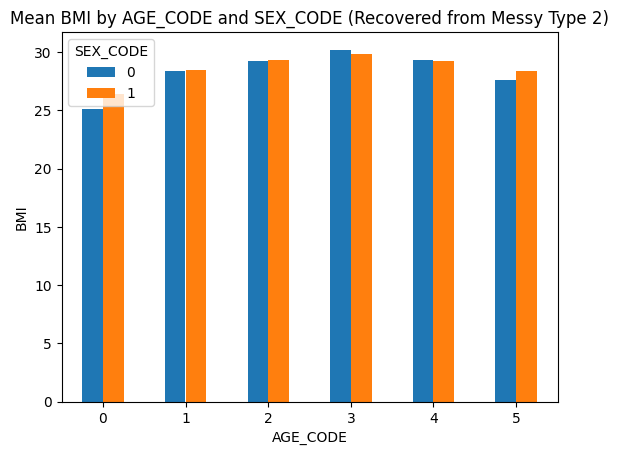

In [ ]:
# 시각화: 두 변수가 분리되어야만 집단 비교가 자연스럽다.
plot2 = (
    tidy2
    .groupby(["AGE_CODE", "SEX_CODE"], as_index=False)["BMI"]
    .mean()
    .pivot(index="AGE_CODE", columns="SEX_CODE", values="BMI")
)

plot2.plot(kind="bar")
plt.title("Mean BMI by AGE_CODE and SEX_CODE (Recovered from Messy Type 2)")
plt.xlabel("AGE_CODE")
plt.ylabel("BMI")
plt.xticks(rotation=0)
plt.legend(title="SEX_CODE")
plt.show()

# 해석:
# - 융합된 문자열을 찢어 두 변수로 복원해야
#   집단 비교, 범주별 색상 구분, 다차원 groupby가 가능해진다.
# - 즉, str.extract는 텍스트 전처리가 아니라 '변수 분리' 도구다.

# 🤔 생각해 보기

1. `str.split()`과 `str.extract()`는 언제 다르게 사용할까요?
2. 융합된 변수 열이 여러 개 있을 때, 반복문 대신 벡터화 문자열 처리를 써야 하는 이유는 무엇일까요?
3. 이 패턴은 설문 데이터, 로그 데이터, 의료 코드 데이터에서 왜 자주 등장할까요?

In [ ]:
print("1) 구분자가 명확하면 split, 규칙 패턴이 있으면 extract(정규표현식)가 더 유리합니다.")
print("2) Pandas의 벡터화 문자열 연산은 반복문보다 빠르고, 코드도 짧고 안정적입니다.")
print("3) 여러 속성을 짧은 코드 하나에 압축 저장하는 관행 때문에 자주 등장합니다.")

1) 구분자가 명확하면 split, 규칙 패턴이 있으면 extract(정규표현식)가 더 유리합니다.
2) Pandas의 벡터화 문자열 연산은 반복문보다 빠르고, 코드도 짧고 안정적입니다.
3) 여러 속성을 짧은 코드 하나에 압축 저장하는 관행 때문에 자주 등장합니다.


# 5. 유형 3 실습
## 변수가 행과 열에 동시에 파편화된 경우 → `melt()` 후 `pivot()`으로 해결

이번에는 실제 CSV를 이용해 아래와 같은 messy table을 만들겠습니다.

- `EDU_LEVEL_CODE` : 교육 수준 코드
- `HEALTH_METRIC` : 건강 지표 이름 (`BMI`, `PHYS_HLTH_DAYS`, `MENT_HLTH_DAYS`)
- 열 이름 `0`, `1` : SEX_CODE 값
- 셀 값 : 각 집단의 평균

이 표는 보기에는 그럴듯하지만,
변수 하나(`SEX_CODE`)는 열 이름으로 퍼져 있고,
다른 변수 하나(`HEALTH_METRIC`)는 행 방향에 섞여 있어서
**행/열 양쪽에 변수가 파편화**된 상태입니다.

In [ ]:
metrics = ["BMI", "PHYS_HLTH_DAYS", "MENT_HLTH_DAYS"]

type3_base = (
    brfss[["EDU_LEVEL_CODE", "SEX_CODE"] + metrics]
    .dropna()
)

type3_agg = (
    type3_base
    .groupby(["EDU_LEVEL_CODE", "SEX_CODE"], as_index=False)[metrics]
    .mean()
    .round(2)
)

type3_long = type3_agg.melt(
    id_vars=["EDU_LEVEL_CODE", "SEX_CODE"],
    value_vars=metrics,
    var_name="HEALTH_METRIC",
    value_name="MEAN_VALUE"
)

type3_messy = (
    type3_long
    .pivot(index=["EDU_LEVEL_CODE", "HEALTH_METRIC"], columns="SEX_CODE", values="MEAN_VALUE")
    .reset_index()
)

type3_messy.columns = ["EDU_LEVEL_CODE", "HEALTH_METRIC"] + [str(col) for col in type3_messy.columns[2:]]

type3_path = BASE_DIR / "messy_type3_fragmented_metrics.csv"
type3_messy.to_csv(type3_path, index=False)

print("저장 완료:", type3_path.resolve())
type3_messy.head(10)

저장 완료: /mnt/data/messy_type3_fragmented_metrics.csv


,EDU_LEVEL_CODE,HEALTH_METRIC,0,1
0,0.0,BMI,30.56,29.64
1,0.0,MENT_HLTH_DAYS,3.68,4.47
2,0.0,PHYS_HLTH_DAYS,7.15,7.50
3,1.0,BMI,30.60,29.10
4,1.0,MENT_HLTH_DAYS,5.57,4.58
5,1.0,PHYS_HLTH_DAYS,7.72,7.00
6,2.0,BMI,29.86,28.43
7,2.0,MENT_HLTH_DAYS,7.14,5.67
8,2.0,PHYS_HLTH_DAYS,8.01,6.73
9,3.0,BMI,29.18,28.82


In [ ]:
messy3 = pd.read_csv(type3_path)
print_basic_check("messy3", messy3)
messy3.head(10)

[messy3]
shape: (18, 4)
memory(MB): 0.002
columns: ['EDU_LEVEL_CODE', 'HEALTH_METRIC', '0', '1']
--------------------------------------------------------------------------------


,EDU_LEVEL_CODE,HEALTH_METRIC,0,1
0,0.0,BMI,30.56,29.64
1,0.0,MENT_HLTH_DAYS,3.68,4.47
2,0.0,PHYS_HLTH_DAYS,7.15,7.50
3,1.0,BMI,30.60,29.10
4,1.0,MENT_HLTH_DAYS,5.57,4.58
5,1.0,PHYS_HLTH_DAYS,7.72,7.00
6,2.0,BMI,29.86,28.43
7,2.0,MENT_HLTH_DAYS,7.14,5.67
8,2.0,PHYS_HLTH_DAYS,8.01,6.73
9,3.0,BMI,29.18,28.82


## 왜 이 구조가 messy한가?

현재 구조에서는

- `SEX_CODE` 값은 열 이름(`0`, `1`)에 들어가 있고
- `HEALTH_METRIC` 값은 행 방향에 흩어져 있습니다.

즉, 하나의 관측치가 다음처럼 분해되어 있는 셈입니다.

- 교육 수준 = 3
- 성별 코드 = 0
- BMI 평균 = ...
- PHYS_HLTH_DAYS 평균 = ...
- MENT_HLTH_DAYS 평균 = ...

이 정보를 한 행으로 모으려면 **2단계 변환**이 필요합니다.

1. `melt()` : 열로 흩어진 `SEX_CODE`를 다시 행으로 내린다.
2. `pivot()` : 행에 흩어진 `HEALTH_METRIC`를 다시 열로 올린다.

In [ ]:
# 1단계: SEX_CODE 값을 다시 행으로 내린다.
step3_1 = messy3.melt(
    id_vars=["EDU_LEVEL_CODE", "HEALTH_METRIC"],
    value_vars=["0", "1"],
    var_name="SEX_CODE",
    value_name="MEAN_VALUE"
)

step3_1["SEX_CODE"] = step3_1["SEX_CODE"].astype(int)

step3_1.head(10)

,EDU_LEVEL_CODE,HEALTH_METRIC,SEX_CODE,MEAN_VALUE
0,0.0,BMI,0,30.56
1,0.0,MENT_HLTH_DAYS,0,3.68
2,0.0,PHYS_HLTH_DAYS,0,7.15
3,1.0,BMI,0,30.60
4,1.0,MENT_HLTH_DAYS,0,5.57
5,1.0,PHYS_HLTH_DAYS,0,7.72
6,2.0,BMI,0,29.86
7,2.0,MENT_HLTH_DAYS,0,7.14
8,2.0,PHYS_HLTH_DAYS,0,8.01
9,3.0,BMI,0,29.18


In [ ]:
# 2단계: HEALTH_METRIC을 다시 열로 올린다.
tidy3 = (
    step3_1
    .pivot(
        index=["EDU_LEVEL_CODE", "SEX_CODE"],
        columns="HEALTH_METRIC",
        values="MEAN_VALUE"
    )
    .reset_index()
)

tidy3.columns.name = None
tidy3 = tidy3.sort_values(["EDU_LEVEL_CODE", "SEX_CODE"]).reset_index(drop=True)

tidy3

,EDU_LEVEL_CODE,SEX_CODE,BMI,MENT_HLTH_DAYS,PHYS_HLTH_DAYS
0,0.0,0,30.56,3.68,7.15
1,0.0,1,29.64,4.47,7.50
2,1.0,0,30.60,5.57,7.72
3,1.0,1,29.10,4.58,7.00
4,2.0,0,29.86,7.14,8.01
5,2.0,1,28.43,5.67,6.73
6,3.0,0,29.18,5.71,5.88
7,3.0,1,28.82,4.43,4.87
8,4.0,0,29.07,5.70,5.72
9,4.0,1,29.08,4.22,4.74


In [ ]:
# 검증: tidy3가 type3_agg와 같은지 확인
expected3 = (
    type3_agg
    .sort_values(["EDU_LEVEL_CODE", "SEX_CODE"])
    .reset_index(drop=True)
)

pd.testing.assert_frame_equal(
    tidy3[expected3.columns].reset_index(drop=True),
    expected3.reset_index(drop=True)
)

print("검증 통과: melt + pivot 결과가 원래 집계 구조와 정확히 일치합니다.")

검증 통과: melt + pivot 결과가 원래 집계 구조와 정확히 일치합니다.


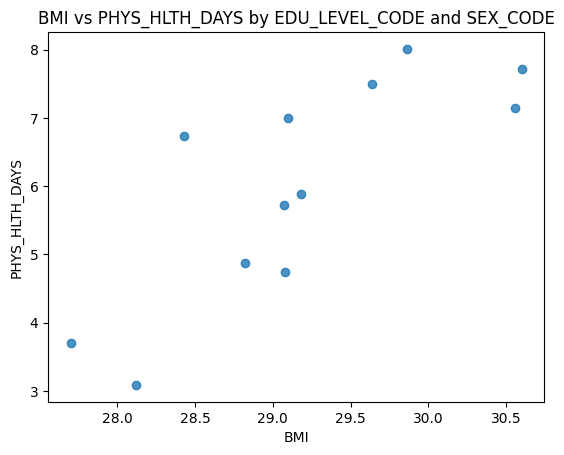

In [ ]:
# 시각화: tidy3가 되면 여러 수치 열을 동시에 다루기 쉬워진다.
plt.scatter(tidy3["BMI"], tidy3["PHYS_HLTH_DAYS"], alpha=0.8)
plt.xlabel("BMI")
plt.ylabel("PHYS_HLTH_DAYS")
plt.title("BMI vs PHYS_HLTH_DAYS by EDU_LEVEL_CODE and SEX_CODE")
plt.show()

# 해석:
# - tidy3에서는 BMI, PHYS_HLTH_DAYS, MENT_HLTH_DAYS가 모두 독립 열이므로
#   산점도, 상관 분석, 회귀 입력 행렬 구성 등이 쉬워진다.
# - 즉, 행/열에 파편화된 변수를 복원하는 작업은 단순 재배열이 아니라
#   다변량 분석을 가능하게 만드는 핵심 단계다.

# 🤔 생각해 보기

1. 왜 유형 3은 유형 1보다 더 어렵다고 볼 수 있을까요?
2. `melt()`만으로는 왜 충분하지 않을까요?
3. 다변량 모델링(예: 회귀분석, 머신러닝 입력 행렬)에서 tidy3 같은 구조가 왜 중요한가요?

In [ ]:
print("1) 변수 하나는 열에, 다른 변수 하나는 행에 흩어져 있어 두 축을 동시에 복구해야 하기 때문입니다.")
print("2) melt는 열->행 변환만 수행하므로, 행에 섞인 metric을 다시 열로 올릴 pivot이 추가로 필요합니다.")
print("3) 모델링에서는 설명변수들이 각각 독립된 열이어야 설계 행렬을 만들 수 있기 때문입니다.")

1) 변수 하나는 열에, 다른 변수 하나는 행에 흩어져 있어 두 축을 동시에 복구해야 하기 때문입니다.
2) melt는 열->행 변환만 수행하므로, 행에 섞인 metric을 다시 열로 올릴 pivot이 추가로 필요합니다.
3) 모델링에서는 설명변수들이 각각 독립된 열이어야 설계 행렬을 만들 수 있기 때문입니다.


# 6. 유형 4 실습
## 서로 다른 관측 단위가 한 표에 섞인 경우 → 테이블 분리 후 `merge()`로 연결

이번에는 실제 CSV 일부를 이용해 의도적으로 **응답자 단위 정보**와
**교육 수준 단위 요약 정보**를 한 표에 섞어 보겠습니다.

예를 들어 다음 두 정보는 관측 단위가 다릅니다.

### 응답자 단위(개별 행)
- RESPONDENT_ID
- SEX_CODE
- AGE_CODE
- BMI
- EDU_LEVEL_CODE

### 교육 수준 단위(집단 요약)
- EDU_LEVEL_CODE별 평균 BMI
- EDU_LEVEL_CODE별 응답자 수
- EDU_LEVEL_CODE별 당뇨 비율

이 둘을 한 표에 섞어 넣으면 요약 정보가 응답자마다 반복 저장되어,
분석과 저장 모두 비효율적이 됩니다.

In [ ]:
type4_source = (
    brfss[
        ["RESPONDENT_ID", "SEX_CODE", "AGE_CODE", "BMI", "EDU_LEVEL_CODE", "INCOME_LEVEL_CODE", "DIABETES_STATUS"]
    ]
    .dropna(subset=["BMI", "EDU_LEVEL_CODE"])
    .sample(3000, random_state=42)
    .reset_index(drop=True)
)

education_summary = (
    type4_source
    .groupby("EDU_LEVEL_CODE", as_index=False)
    .agg(
        EDU_AVG_BMI=("BMI", "mean"),
        EDU_COUNT=("RESPONDENT_ID", "size"),
        EDU_DIABETES_RATE=("DIABETES_STATUS", "mean")
    )
    .round(3)
)

type4_messy = type4_source.merge(education_summary, on="EDU_LEVEL_CODE", how="left")

type4_path = BASE_DIR / "messy_type4_mixed_units.csv"
type4_messy.to_csv(type4_path, index=False)

print("저장 완료:", type4_path.resolve())
type4_messy.head()

저장 완료: /mnt/data/messy_type4_mixed_units.csv


,RESPONDENT_ID,SEX_CODE,AGE_CODE,BMI,EDU_LEVEL_CODE,INCOME_LEVEL_CODE,DIABETES_STATUS,EDU_AVG_BMI,EDU_COUNT,EDU_DIABETES_RATE
0,186564,1,5,31.15,3.0,2.0,0,28.856,751,0.451
1,317000,0,5,19.60,5.0,NaN,0,27.888,1263,0.356
2,175902,0,3,25.09,5.0,7.0,0,27.888,1263,0.356
3,166324,1,5,24.60,5.0,7.0,0,27.888,1263,0.356
4,40972,1,5,25.82,5.0,6.0,0,27.888,1263,0.356


In [ ]:
messy4 = pd.read_csv(type4_path)
print_basic_check("messy4", messy4)
messy4.head()

[messy4]
shape: (3000, 10)
memory(MB): 0.229
columns: ['RESPONDENT_ID', 'SEX_CODE', 'AGE_CODE', 'BMI', 'EDU_LEVEL_CODE', 'INCOME_LEVEL_CODE', 'DIABETES_STATUS', 'EDU_AVG_BMI', 'EDU_COUNT', 'EDU_DIABETES_RATE']
--------------------------------------------------------------------------------


,RESPONDENT_ID,SEX_CODE,AGE_CODE,BMI,EDU_LEVEL_CODE,INCOME_LEVEL_CODE,DIABETES_STATUS,EDU_AVG_BMI,EDU_COUNT,EDU_DIABETES_RATE
0,186564,1,5,31.15,3.0,2.0,0,28.856,751,0.451
1,317000,0,5,19.60,5.0,NaN,0,27.888,1263,0.356
2,175902,0,3,25.09,5.0,7.0,0,27.888,1263,0.356
3,166324,1,5,24.60,5.0,7.0,0,27.888,1263,0.356
4,40972,1,5,25.82,5.0,6.0,0,27.888,1263,0.356


## 왜 이 구조가 messy한가?

`EDU_AVG_BMI`, `EDU_COUNT`, `EDU_DIABETES_RATE`는
개별 응답자 고유값이 아니라 **교육 수준 집단의 요약값**입니다.

그런데 지금은 각 응답자 행마다 이 집단 요약값이 반복 저장되고 있습니다.

이렇게 되면

- 저장 공간 낭비
- 중복 데이터 증가
- 요약 열을 잘못 다시 집계했을 때 통계 왜곡

문제가 생길 수 있습니다.

따라서 다음 두 테이블로 분리하는 것이 더 올바릅니다.

1. `respondents` : 응답자 단위
2. `education_table` : 교육 수준 단위

In [ ]:
# 해결: 서로 다른 관측 단위를 분리한다.
respondents = (
    messy4[
        ["RESPONDENT_ID", "SEX_CODE", "AGE_CODE", "BMI", "EDU_LEVEL_CODE", "INCOME_LEVEL_CODE", "DIABETES_STATUS"]
    ]
    .drop_duplicates()
    .reset_index(drop=True)
)

education_table = (
    messy4[
        ["EDU_LEVEL_CODE", "EDU_AVG_BMI", "EDU_COUNT", "EDU_DIABETES_RATE"]
    ]
    .drop_duplicates()
    .sort_values("EDU_LEVEL_CODE")
    .reset_index(drop=True)
)

print_basic_check("respondents", respondents)
print_basic_check("education_table", education_table)

display(respondents.head())
display(education_table.head())

[respondents]
shape: (3000, 7)
memory(MB): 0.16
columns: ['RESPONDENT_ID', 'SEX_CODE', 'AGE_CODE', 'BMI', 'EDU_LEVEL_CODE', 'INCOME_LEVEL_CODE', 'DIABETES_STATUS']
--------------------------------------------------------------------------------
[education_table]
shape: (6, 4)
memory(MB): 0.0
columns: ['EDU_LEVEL_CODE', 'EDU_AVG_BMI', 'EDU_COUNT', 'EDU_DIABETES_RATE']
--------------------------------------------------------------------------------


,RESPONDENT_ID,SEX_CODE,AGE_CODE,BMI,EDU_LEVEL_CODE,INCOME_LEVEL_CODE,DIABETES_STATUS
0,186564,1,5,31.15,3.0,2.0,0
1,317000,0,5,19.60,5.0,NaN,0
2,175902,0,3,25.09,5.0,7.0,0
3,166324,1,5,24.60,5.0,7.0,0
4,40972,1,5,25.82,5.0,6.0,0


,EDU_LEVEL_CODE,EDU_AVG_BMI,EDU_COUNT,EDU_DIABETES_RATE
0,0.0,24.265,2,1.500
1,1.0,29.399,42,1.024
2,2.0,28.451,91,0.681
3,3.0,28.856,751,0.451
4,4.0,28.993,851,0.551


In [ ]:
# 필요할 때만 merge로 관계를 복원한다.
joined4 = respondents.merge(
    education_table,
    on="EDU_LEVEL_CODE",
    how="left",
    validate="many_to_one"  # 응답자 여러 명 -> 교육수준 요약 1개
)

assert len(joined4) == len(respondents), "merge 후 행 수가 달라졌습니다."
print("검증 통과: many_to_one merge이며, 응답자 행 수가 유지됩니다.")
joined4.head()

검증 통과: many_to_one merge이며, 응답자 행 수가 유지됩니다.


,RESPONDENT_ID,SEX_CODE,AGE_CODE,BMI,EDU_LEVEL_CODE,INCOME_LEVEL_CODE,DIABETES_STATUS,EDU_AVG_BMI,EDU_COUNT,EDU_DIABETES_RATE
0,186564,1,5,31.15,3.0,2.0,0,28.856,751,0.451
1,317000,0,5,19.60,5.0,NaN,0,27.888,1263,0.356
2,175902,0,3,25.09,5.0,7.0,0,27.888,1263,0.356
3,166324,1,5,24.60,5.0,7.0,0,27.888,1263,0.356
4,40972,1,5,25.82,5.0,6.0,0,27.888,1263,0.356


In [ ]:
# 중복 저장이 왜 문제인지 예시로 확인
wrong_sum = messy4["EDU_COUNT"].sum()
right_sum = education_table["EDU_COUNT"].sum()

print("잘못된 합계(반복 저장된 열을 그대로 합산):", wrong_sum)
print("올바른 합계(교육 수준 요약 테이블에서 1번씩만 합산):", right_sum)

# 해석:
# - messy4에서 EDU_COUNT는 각 응답자 행에 반복되어 있으므로 그대로 합치면 심하게 부풀려진다.
# - 서로 다른 관측 단위를 섞으면 통계량이 왜곡될 수 있다는 점을 보여준다.

잘못된 합계(반복 저장된 열을 그대로 합산): 2893420
올바른 합계(교육 수준 요약 테이블에서 1번씩만 합산): 3000


# 🤔 생각해 보기

1. 유형 4는 왜 '정규화(normalization)'와 연결해서 이해할 수 있을까요?
2. `validate="many_to_one"` 옵션은 왜 중요할까요?
3. 실무에서 어떤 데이터가 유형 4에 자주 해당할까요?

In [ ]:
print("1) 응답자 단위와 집단 단위를 분리해 중복 저장을 줄이는 점에서 DB 정규화와 연결됩니다.")
print("2) join 관계가 의도와 다른지(예: many_to_many 폭증) 사전에 잡아낼 수 있기 때문입니다.")
print("3) 주문-고객, 환자-병원, 학생-학과, 상품-브랜드 요약 데이터에서 자주 발생합니다.")

1) 응답자 단위와 집단 단위를 분리해 중복 저장을 줄이는 점에서 DB 정규화와 연결됩니다.
2) join 관계가 의도와 다른지(예: many_to_many 폭증) 사전에 잡아낼 수 있기 때문입니다.
3) 주문-고객, 환자-병원, 학생-학과, 상품-브랜드 요약 데이터에서 자주 발생합니다.


# 7. 유형 5 실습
## 동일한 구조의 데이터가 여러 파일에 나뉘어 있는 경우 → `concat()`으로 해결

이번에는 동일한 스키마를 가진 데이터를 여러 CSV로 분할한 뒤,
다시 하나의 DataFrame으로 합치는 연습을 합니다.

실무에서는 다음과 같은 형태가 흔합니다.

- 월별 파일: `2024_01.csv`, `2024_02.csv`, ...
- 파티션 파일: `part_1.csv`, `part_2.csv`, ...
- 시스템별 추출 파일: `source_a.csv`, `source_b.csv`

핵심은 다음입니다.

- **나쁜 패턴**: 빈 DataFrame에 반복문으로 계속 `concat`
- **좋은 패턴**: 파일들을 리스트에 담고 `pd.concat()` 한 번만 수행

In [ ]:
type5_source = (
    brfss[
        ["RESPONDENT_ID", "SEX_CODE", "AGE_CODE", "BMI", "EDU_LEVEL_CODE"]
    ]
    .dropna()
    .sample(12000, random_state=42)
    .sort_values("RESPONDENT_ID")
    .reset_index(drop=True)
)

part1, part2, part3 = np.array_split(type5_source, 3)

part_paths = [
    BASE_DIR / "messy_type5_part1.csv",
    BASE_DIR / "messy_type5_part2.csv",
    BASE_DIR / "messy_type5_part3.csv"
]

for part_df, path in zip([part1, part2, part3], part_paths):
    part_df.to_csv(path, index=False)
    print("저장 완료:", path.resolve(), "shape=", part_df.shape)

저장 완료: /mnt/data/messy_type5_part1.csv shape= (4000, 5)
저장 완료: /mnt/data/messy_type5_part2.csv shape= (4000, 5)
저장 완료: /mnt/data/messy_type5_part3.csv shape= (4000, 5)


/opt/pyvenv/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


In [ ]:
# 안티 패턴(설명용)
bad_pattern = '''
bad_total = pd.DataFrame()
for f in files:
    temp = pd.read_csv(f)
    bad_total = pd.concat([bad_total, temp], ignore_index=True)
'''

print("반복 concat 안티 패턴 예시:")
print(bad_pattern)
print("이 방식은 파일 수가 많아질수록 불필요한 중간 객체가 계속 생겨 비효율적입니다.")

반복 concat 안티 패턴 예시:

bad_total = pd.DataFrame()
for f in files:
    temp = pd.read_csv(f)
    bad_total = pd.concat([bad_total, temp], ignore_index=True)

이 방식은 파일 수가 많아질수록 불필요한 중간 객체가 계속 생겨 비효율적입니다.


In [ ]:
# 권장 패턴: 리스트에 모아서 한 번만 concat
files = sorted(BASE_DIR.glob("messy_type5_part*.csv"))
df_list = [pd.read_csv(f) for f in files]
tidy5 = pd.concat(df_list, ignore_index=True)

print_basic_check("tidy5", tidy5)
tidy5.head()

[tidy5]
shape: (12000, 5)
memory(MB): 0.458
columns: ['RESPONDENT_ID', 'SEX_CODE', 'AGE_CODE', 'BMI', 'EDU_LEVEL_CODE']
--------------------------------------------------------------------------------


,RESPONDENT_ID,SEX_CODE,AGE_CODE,BMI,EDU_LEVEL_CODE
0,82,0,4,40.39,4.0
1,118,1,5,24.21,5.0
2,124,0,5,13.52,2.0
3,239,0,5,25.75,3.0
4,263,1,5,23.63,4.0


In [ ]:
# 검증 1: 행 수가 분할 파일 합계와 같은가?
expected_rows = sum(len(pd.read_csv(f)) for f in files)
print("분할 파일 행 수 합:", expected_rows)
print("concat 결과 행 수:", len(tidy5))
assert len(tidy5) == expected_rows

# 검증 2: 원래 type5_source와 같은가?
original_sorted = type5_source.sort_values("RESPONDENT_ID").reset_index(drop=True)
tidy5_sorted = tidy5.sort_values("RESPONDENT_ID").reset_index(drop=True)

pd.testing.assert_frame_equal(original_sorted, tidy5_sorted)
print("검증 통과: concat 결과가 원래 데이터와 정확히 일치합니다.")

분할 파일 행 수 합: 12000
concat 결과 행 수: 12000
검증 통과: concat 결과가 원래 데이터와 정확히 일치합니다.


# 🤔 생각해 보기

1. 왜 `concat`은 반복 호출보다 1회 호출이 유리할까요?
2. `ignore_index=True`는 왜 자주 함께 쓰일까요?
3. `merge`와 `concat`은 언제 구분해서 써야 할까요?

In [ ]:
print("1) 반복 concat은 중간 DataFrame 재생성이 많아 메모리/시간 낭비가 커집니다.")
print("2) 분할 파일의 원래 인덱스가 겹칠 수 있으므로, 새 연속 인덱스를 부여하는 것이 안전합니다.")
print("3) concat은 같은 스키마를 세로로 잇는 연산, merge는 공통 키를 기준으로 옆으로 붙이는 연산입니다.")

1) 반복 concat은 중간 DataFrame 재생성이 많아 메모리/시간 낭비가 커집니다.
2) 분할 파일의 원래 인덱스가 겹칠 수 있으므로, 새 연속 인덱스를 부여하는 것이 안전합니다.
3) concat은 같은 스키마를 세로로 잇는 연산, merge는 공통 키를 기준으로 옆으로 붙이는 연산입니다.


# 8. 메서드 체이닝과 공학적 관점

3주차의 중요한 메시지 중 하나는
전처리를 단순한 cleaning이 아니라 **시간/공간 복잡도를 고려한 설계**로 보라는 것입니다.

아래 예시는 같은 일을 하지만, 권장 패턴이 더 읽기 쉽고 중간 객체도 줄일 수 있습니다.

In [ ]:
# 안티 패턴 예시
anti_result_1 = brfss.dropna(subset=["BMI", "EDU_LEVEL_CODE"])
anti_result_2 = anti_result_1[anti_result_1["BMI"] >= 18.5]
anti_result_3 = anti_result_2.groupby("EDU_LEVEL_CODE", as_index=False)["BMI"].mean()

print("안티 패턴 결과:")
display(anti_result_3.head())

# 권장 패턴 예시
good_result = (
    brfss
    .dropna(subset=["BMI", "EDU_LEVEL_CODE"])
    .loc[lambda x: x["BMI"] >= 18.5]
    .groupby("EDU_LEVEL_CODE", as_index=False)["BMI"]
    .mean()
)

print("권장 패턴 결과:")
display(good_result.head())

# 해석:
# - 둘 다 같은 결과를 낼 수 있지만,
#   메서드 체이닝은 처리 흐름이 위에서 아래로 자연스럽게 읽힌다.
# - 특히 전처리 단계가 길어질수록 체이닝 방식이 유지보수에 유리하다.

안티 패턴 결과:


,EDU_LEVEL_CODE,BMI
0,0.0,30.421121
1,1.0,30.117197
2,2.0,29.489934
3,3.0,29.263282
4,4.0,29.267574


권장 패턴 결과:


,EDU_LEVEL_CODE,BMI
0,0.0,30.421121
1,1.0,30.117197
2,2.0,29.489934
3,3.0,29.263282
4,4.0,29.267574


# 9. 최종 정리

이번 노트북에서 실제로 수행한 것은 다음과 같습니다.

## Tidy Data 핵심 원칙
- 한 열에는 하나의 변수만 둔다.
- 한 행에는 하나의 관측치만 둔다.
- 서로 다른 관측 단위는 서로 다른 테이블로 분리한다.

## Messy Data 해결 도구
- 유형 1: `melt()`
- 유형 2: `str.extract()`
- 유형 3: `melt()` + `pivot()`
- 유형 4: `drop_duplicates()` + `merge()`
- 유형 5: `concat()`

## 가장 중요한 관점
전처리는 단순히 예쁜 표를 만드는 작업이 아니라,
**분석 가능한 구조를 복원하는 설계 작업**입니다.

즉, 3주차의 핵심은 아래 문장으로 정리할 수 있습니다.

> messy data를 tidy data로 바꾸는 순간,  
> 시각화, 통계, 머신러닝, 데이터베이스 설계가 하나의 언어로 연결된다.

# 10. 추가 연습해보기

### 연습 1
`INCOME_LEVEL_CODE`를 열 이름으로 갖는 wide table을 직접 만든 뒤,
다시 `melt()`로 long form으로 복원해 보세요.

### 연습 2
`SEX_CODE`, `EDU_LEVEL_CODE`, `INCOME_LEVEL_CODE` 세 변수를 하나의 문자열 열로 합친 뒤,
`str.extract()` 또는 `str.split()`으로 다시 분해해 보세요.

### 연습 3
`BMI`, `PHYS_HLTH_DAYS`, `POOR_HLTH_DAYS`를 이용해 유형 3 구조를 직접 만들고,
melt → pivot 순서로 다시 tidy하게 복원해 보세요.

### 연습 4
응답자 단위와 소득 수준 단위의 요약 정보를 한 표에 섞은 뒤,
두 테이블로 분리하고 `validate` 옵션을 사용하여 안전하게 merge해 보세요.

### 연습 5
분할 CSV 파일 수를 3개가 아니라 10개로 늘렸다고 가정하고,
반복 concat 방식과 1회 concat 방식을 비교 설명해 보세요.